# Sentiment Analysis of Text Reviews — Complete End-to-End NLP Notebook

Classifies reviews as **positive** or **negative**.

**What you will build:**
- Robust text cleaning pipeline
- Classic ML models (TF-IDF + LogReg / NaiveBayes / LinearSVC)
- Hyperparameter tuning with cross-validation
- Bidirectional LSTM deep learning model
- Model evaluation, error analysis, and feature inspection
- FastAPI backend + web UI + Docker deployment files

Works in Jupyter, Google Colab, Kaggle, or any local Python environment.  
Drop your own `reviews.csv` (`review`, `sentiment` columns) in the notebook folder, or the IMDB fallback is used automatically.

## 1. Install Dependencies

Run once; restart the kernel if prompted after TensorFlow installs.

In [1]:
import sys, subprocess, importlib.util

_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "joblib": "joblib",
    "tensorflow": "tensorflow",
    "fastapi": "fastapi",
    "uvicorn": "uvicorn",
}

for pkg, import_name in _packages.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pkg}…")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All dependencies ready.")

Installing tensorflow…
Installing fastapi…
All dependencies ready.


## 2. Imports and Configuration

In [2]:
import os, re, json, string, warnings, logging, time
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
import joblib

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("sentiment")

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Project layout ────────────────────────────────────────────────────────────
PROJECT_DIR = Path("sentiment_analysis_project")
MODEL_DIR   = PROJECT_DIR / "models"
APP_DIR     = PROJECT_DIR / "app"
STATIC_DIR  = APP_DIR / "static"

for _dir in [PROJECT_DIR, MODEL_DIR, APP_DIR, STATIC_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

logger.info("Project root: %s", PROJECT_DIR.resolve())

## 3. Load Dataset

Priority order:
1. `reviews.csv` in the notebook folder — columns: `review`, `sentiment` (positive/negative or 1/0)
2. Keras IMDB sample (requires TensorFlow; downloaded on first run)
3. Built-in fallback dataset

```csv
review,sentiment
This product is excellent,positive
Very bad experience,negative
```

In [4]:
def load_user_csv(path: str = "reviews.csv") -> Optional[pd.DataFrame]:
    """Load a user-supplied CSV. Returns None if the file does not exist."""
    csv_path = Path(path)
    if not csv_path.exists():
        return None

    df_local = pd.read_csv(csv_path)
    required = {"review", "sentiment"}
    missing = required - set(df_local.columns)
    if missing:
        raise ValueError(f"reviews.csv is missing columns: {missing}")

    df_local = df_local[["review", "sentiment"]].dropna().copy()
    df_local["sentiment"] = df_local["sentiment"].astype(str).str.lower().str.strip()
    valid_mask = df_local["sentiment"].isin({"positive", "negative", "1", "0"})
    invalid = (~valid_mask).sum()
    if invalid:
        logger.warning("Dropping %d rows with unrecognised sentiment values.", invalid)
    df_local = df_local[valid_mask].copy()
    df_local["label"] = df_local["sentiment"].map(
        {"negative": 0, "positive": 1, "0": 0, "1": 1}
    )
    return df_local[["review", "label"]]


def load_keras_imdb_sample(
    max_features: int = 10_000, sample_size: int = 6_000
) -> Optional[pd.DataFrame]:
    """Decode a random sample from the Keras IMDB dataset."""
    try:
        from tensorflow.keras.datasets import imdb  # type: ignore

        (x_tr, y_tr), (x_te, y_te) = imdb.load_data(num_words=max_features)
        word_index = imdb.get_word_index()
        rev_idx = {v + 3: k for k, v in word_index.items()}
        rev_idx.update({0: "<PAD>", 1: "<START>", 2: "<UNK>", 3: "<UNUSED>"})

        def decode(enc):
            return " ".join(rev_idx.get(i, "?") for i in enc)

        x_all = np.concatenate([x_tr, x_te])
        y_all = np.concatenate([y_tr, y_te])
        rng   = np.random.default_rng(RANDOM_STATE)          # local RNG, reproducible
        idx   = rng.choice(len(x_all), size=min(sample_size, len(x_all)), replace=False)
        return pd.DataFrame({"review": [decode(x_all[i]) for i in idx], "label": y_all[idx]})

    except Exception as exc:
        logger.warning("IMDB load failed (%s). Falling back to built-in dataset.", exc)
        return None


def load_fallback_dataset() -> pd.DataFrame:
    """Tiny balanced dataset — useful for smoke-tests only."""
    positive_reviews = [
        "This movie was fantastic and emotionally powerful.",
        "I loved the product, it works perfectly and exceeded expectations.",
        "Excellent quality and fast delivery, highly recommended.",
        "The story was engaging and the acting was brilliant.",
        "Amazing service, friendly staff, and great value for money.",
        "I am very happy with this purchase.",
        "The experience was smooth, pleasant, and satisfying.",
        "The phone has a great camera and strong battery life.",
        "Wonderful performance with beautiful direction.",
        "The app is simple, useful, and reliable.",
        "A delightful experience from start to finish.",
        "This is one of the best products I have ever used.",
        "The hotel room was clean, comfortable, and quiet.",
        "The book is inspiring and very easy to understand.",
        "The headphones deliver clear, premium sound.",
    ]
    negative_reviews = [
        "This movie was boring and painfully slow.",
        "I hated the product — it stopped working after one day.",
        "Poor quality and delayed delivery; not recommended at all.",
        "The story was confusing and the acting was terrible.",
        "Bad service, rude staff, and a complete waste of money.",
        "I am very disappointed with this purchase.",
        "The experience was frustrating, unpleasant, and stressful.",
        "The phone has a poor camera and the battery drains fast.",
        "Awful performance with careless direction.",
        "The app is buggy, slow, and completely unreliable.",
        "A disappointing experience from start to finish.",
        "This is one of the worst products I have ever used.",
        "The hotel room was dirty, uncomfortable, and noisy.",
        "The book is dull and very hard to understand.",
        "The headphones produce unclear, cheap-sounding audio.",
    ]
    rows = (
        [{"review": t, "label": 1} for t in positive_reviews]
        + [{"review": t, "label": 0} for t in negative_reviews]
    )
    df_local = pd.DataFrame(rows)
    df_local = pd.concat([df_local] * 8, ignore_index=True)
    return df_local.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


# ── Load ──────────────────────────────────────────────────────────────────────
df = load_user_csv("reviews.csv")
if df is None:
    df = load_keras_imdb_sample()
    if df is None:
        df = load_fallback_dataset()

logger.info("Dataset shape: %s", df.shape)
df.head()

,review,label
0,<START> i saw a trailer for this on <UNK> <UNK...,1
1,<START> am i the only one who thought the poin...,0
2,<START> i've seen a few of mr <UNK> movies and...,1
3,<START> one day a red alley cat is fed up of b...,1
4,<START> thirty per <UNK> of this movie appears...,0


## 4. Data Validation and EDA

In [5]:
df = df.dropna(subset=["review", "label"]).copy()
df["review"] = df["review"].astype(str).str.strip()
df["label"]  = df["label"].astype(int)

# Drop empty reviews produced by whitespace-only strings
df = df[df["review"].str.len() > 0].reset_index(drop=True)

df["sentiment"]      = df["label"].map({0: "negative", 1: "positive"})
df["char_count"]     = df["review"].str.len()
df["word_count"]     = df["review"].str.split().str.len()

n_dup = df["review"].duplicated().sum()
if n_dup:
    logger.warning("%d duplicate reviews found — keeping all (deduplication optional).", n_dup)

print(f"Rows          : {len(df):,}")
print(f"Duplicates    : {n_dup:,}")
print(f"Avg words     : {df['word_count'].mean():.1f}")
print("\nClass distribution:")
print(df["sentiment"].value_counts())
print("\nClass balance (%):")
print(df["sentiment"].value_counts(normalize=True).mul(100).round(1))

Rows          : 6,000
Duplicates    : 6
Avg words     : 237.0

Class distribution:
sentiment
positive    3055
negative    2945
Name: count, dtype: int64

Class balance (%):
sentiment
positive    50.9
negative    49.1
Name: proportion, dtype: float64


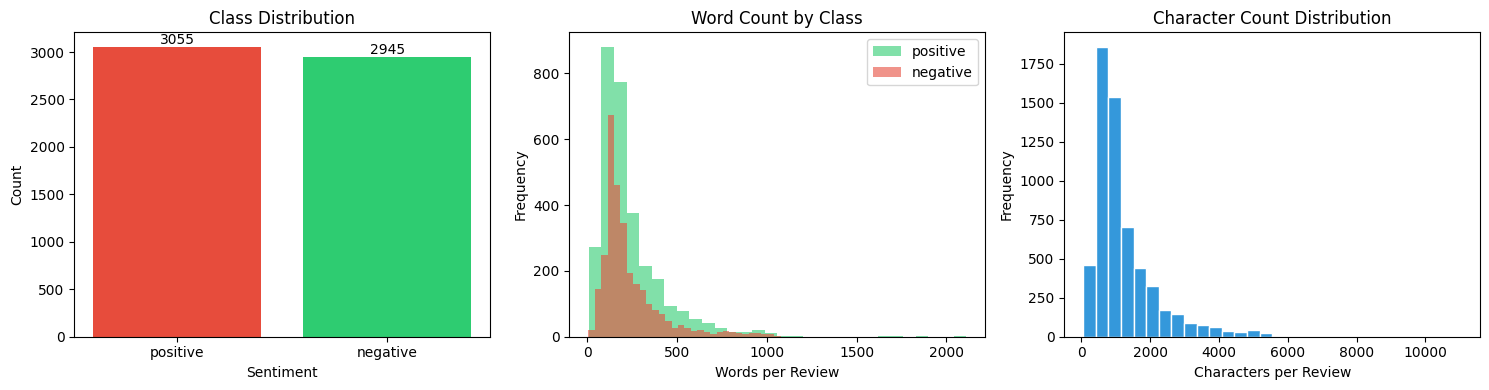

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance
counts = df["sentiment"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=10)

# Word count histogram per class
for label, colour in [(1, "#2ecc71"), (0, "#e74c3c")]:
    axes[1].hist(df.loc[df["label"] == label, "word_count"], bins=30,
                 alpha=0.6, label="positive" if label == 1 else "negative", color=colour)
axes[1].set_title("Word Count by Class")
axes[1].set_xlabel("Words per Review")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Char count histogram
axes[2].hist(df["char_count"], bins=30, color="#3498db", edgecolor="white")
axes[2].set_title("Character Count Distribution")
axes[2].set_xlabel("Characters per Review")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 5. Text Cleaning

`clean_text` is defined **once** here and reused everywhere, including in the
generated FastAPI `main.py`. Changes only need to happen in this cell.

In [7]:
# Compile regexes once — significant speedup on large datasets
_RE_HTML    = re.compile(r"<[^>]+>")
_RE_URL     = re.compile(r"https?://\S+|www\.\S+")
_RE_NONALPH = re.compile(r"[^a-zA-Z\s]")
_RE_SPACES  = re.compile(r"\s+")
_PUNCT_TABLE = str.maketrans("", "", string.punctuation)


def clean_text(text: str) -> str:
    """Normalise a review string for ML consumption.

    Steps: lower-case → strip HTML → strip URLs → remove punctuation
           → keep only ASCII letters/spaces → collapse whitespace.
    """
    text = str(text).lower()
    text = _RE_HTML.sub(" ", text)
    text = _RE_URL.sub(" ", text)
    text = text.translate(_PUNCT_TABLE)
    text = _RE_NONALPH.sub(" ", text)
    text = _RE_SPACES.sub(" ", text).strip()
    return text


# Vectorised apply with progress hint
t0 = time.time()
df["clean_review"] = df["review"].apply(clean_text)
logger.info("Text cleaning done in %.2fs", time.time() - t0)

# Sanity-check: flag reviews that became empty after cleaning
n_empty = (df["clean_review"].str.len() == 0).sum()
if n_empty:
    logger.warning("%d reviews became empty after cleaning — dropping.", n_empty)
    df = df[df["clean_review"].str.len() > 0].reset_index(drop=True)

df[["review", "clean_review", "sentiment"]].head(8)

,review,clean_review,sentiment
0,<START> i saw a trailer for this on <UNK> <UNK...,i saw a trailer for this on the collection of ...,positive
1,<START> am i the only one who thought the poin...,am i the only one who thought the point of thi...,negative
2,<START> i've seen a few of mr <UNK> movies and...,ive seen a few of mr movies and didnt like muc...,positive
3,<START> one day a red alley cat is fed up of b...,one day a red alley cat is fed up of being kic...,positive
4,<START> thirty per <UNK> of this movie appears...,thirty per of this movie appears to be the pro...,negative
5,<START> in an otherwise ghastly <UNK> would be...,in an otherwise ghastly would be comedy br br ...,negative
6,<START> my architect is a great film about <UN...,my architect is a great film about search for ...,positive
7,<START> sex is comedy though not driven by a f...,sex is comedy though not driven by a fantastic...,positive


## 6. Train / Validation / Test Split

We hold out 20 % for testing and use stratified K-fold inside GridSearch.

In [8]:
X = df["clean_review"].values  # numpy array — avoids pandas index alignment issues
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print("Train class balance:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {'positive' if u == 1 else 'negative'}: {c:,} ({c/len(y_train)*100:.1f}%)")

Train : 4,800  |  Test : 1,200
Train class balance:
  negative: 2,356 (49.1%)
  positive: 2,444 (50.9%)


## 7. Classic ML Models with TF-IDF

We train Logistic Regression, Multinomial Naive Bayes, and a calibrated Linear SVC
(calibration adds `predict_proba` support and ROC-AUC computation to LinearSVC).

In [9]:
_TFIDF_DEFAULTS = dict(
    max_features=20_000,
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True,   # ← applies log(1+tf) — helps on varied review lengths
)

models_to_train = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs", random_state=RANDOM_STATE
    ),
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "Linear SVC (calibrated)": CalibratedClassifierCV(
        LinearSVC(max_iter=2000, random_state=RANDOM_STATE), cv=3
    ),
}

results = []
trained_pipelines = {}

for name, clf in models_to_train.items():
    t0 = time.time()
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**_TFIDF_DEFAULTS)),
        ("model", clf),
    ])
    pipe.fit(X_train, y_train)
    preds    = pipe.predict(X_test)
    proba    = pipe.predict_proba(X_test)[:, 1]
    acc      = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average="binary")
    auc      = roc_auc_score(y_test, proba)
    elapsed  = time.time() - t0

    results.append({
        "model": name, "accuracy": acc, "precision": prec,
        "recall": rec, "f1": f1, "roc_auc": auc, "train_s": elapsed,
    })
    trained_pipelines[name] = pipe
    logger.info("%-30s  F1=%.4f  AUC=%.4f  (%.1fs)", name, f1, auc, elapsed)

results_df = (
    pd.DataFrame(results)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
results_df.style.format({
    "accuracy": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}",
    "f1": "{:.4f}", "roc_auc": "{:.4f}", "train_s": "{:.2f}s",
})

,model,accuracy,precision,recall,f1,roc_auc,train_s
0,Linear SVC (calibrated),0.8758,0.8837,0.8707,0.8772,0.9470,1.69s
1,Logistic Regression,0.8725,0.8635,0.8903,0.8767,0.9434,3.84s
2,Multinomial Naive Bayes,0.8508,0.8600,0.8445,0.8522,0.9321,1.52s


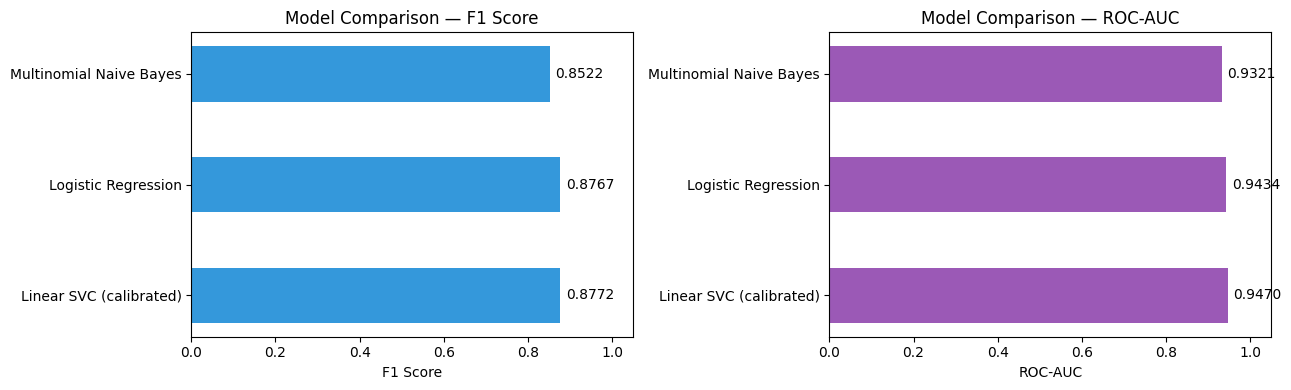

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

metrics = ["f1", "roc_auc"]
titles  = ["F1 Score", "ROC-AUC"]
colours = ["#3498db", "#9b59b6"]

for ax, metric, title, colour in zip(axes, metrics, titles, colours):
    bars = ax.barh(results_df["model"], results_df[metric], color=colour, height=0.5)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(title)
    ax.set_title(f"Model Comparison — {title}")
    ax.bar_label(bars, fmt="%.4f", padding=4)

plt.tight_layout()
plt.show()

## 8. Evaluate Best Classic ML Model

Best model: Linear SVC (calibrated)

              precision    recall  f1-score   support

    negative       0.87      0.88      0.87       589
    positive       0.88      0.87      0.88       611

    accuracy                           0.88      1200
   macro avg       0.88      0.88      0.88      1200
weighted avg       0.88      0.88      0.88      1200



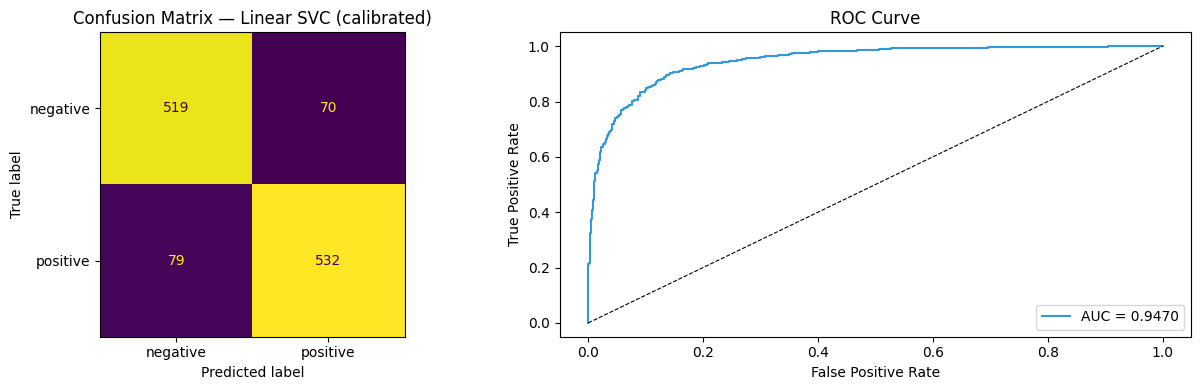

In [11]:
best_name     = results_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_name]
y_pred        = best_pipeline.predict(X_test)
y_proba       = best_pipeline.predict_proba(X_test)[:, 1]

print(f"Best model: {best_name}\n")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix — {best_name}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auc_val:.4f}", color="#3498db")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Feature Inspection — Top TF-IDF Terms

Understanding which tokens drive predictions is essential for debugging and trust-building.
*(This cell only runs when the best model is Logistic Regression.)*

In [12]:
from sklearn.linear_model import LogisticRegression as _LR

_inner = best_pipeline.named_steps["model"]
# Unwrap CalibratedClassifierCV if needed
if hasattr(_inner, "estimator"):
    _inner = _inner.estimator

if isinstance(_inner, _LR):
    tfidf_vocab = best_pipeline.named_steps["tfidf"].get_feature_names_out()
    coefs       = _inner.coef_[0]
    top_n       = 20

    top_pos = np.argsort(coefs)[-top_n:][::-1]
    top_neg = np.argsort(coefs)[:top_n]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, indices, colour, title in [
        (axes[0], top_pos, "#2ecc71", "Top Positive Tokens"),
        (axes[1], top_neg, "#e74c3c", "Top Negative Tokens"),
    ]:
        ax.barh(tfidf_vocab[indices][::-1], coefs[indices][::-1], color=colour)
        ax.set_title(title)
        ax.set_xlabel("Logistic Regression Coefficient")
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature inspection skipped — best model is {best_name} (not Logistic Regression).")

Feature inspection skipped — best model is Linear SVC (calibrated) (not Logistic Regression).


## 10. Hyperparameter Tuning — Logistic Regression

`StratifiedKFold` with 5 folds gives more reliable estimates than the original 3-fold CV,
at the cost of extra compute. Reduce `n_splits` or shrink `param_grid` if you need speed.

In [13]:
param_grid = {
    "tfidf__max_features": [10_000, 20_000],
    "tfidf__ngram_range" : [(1, 1), (1, 2)],
    "model__C"           : [0.5, 1.0, 5.0],
}

tuning_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", sublinear_tf=True)),
    ("model", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(
    tuning_pipe, param_grid=param_grid,
    scoring="f1", cv=cv, n_jobs=-1, verbose=1,
    return_train_score=True,
)

t0 = time.time()
grid.fit(X_train, y_train)
logger.info("Grid search done in %.1fs", time.time() - t0)

print("Best params :", grid.best_params_)
print(f"Best CV F1  : {grid.best_score_:.4f}")

tuned_pipeline = grid.best_estimator_
tuned_pred     = tuned_pipeline.predict(X_test)
tuned_proba    = tuned_pipeline.predict_proba(X_test)[:, 1]

print("\nTest set performance:")
print(classification_report(y_test, tuned_pred, target_names=["negative", "positive"]))
print(f"ROC-AUC : {roc_auc_score(y_test, tuned_proba):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params : {'model__C': 5.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}
Best CV F1  : 0.8713

Test set performance:
              precision    recall  f1-score   support

    negative       0.88      0.87      0.87       589
    positive       0.88      0.88      0.88       611

    accuracy                           0.88      1200
   macro avg       0.88      0.88      0.88      1200
weighted avg       0.88      0.88      0.88      1200

ROC-AUC : 0.9463


## 11. Save Best Model

In [14]:
model_path = MODEL_DIR / "sentiment_model.joblib"
joblib.dump(tuned_pipeline, model_path, compress=3)    # compress=3 ≈ 50% size reduction
logger.info("Model saved → %s  (%.1f KB)", model_path, model_path.stat().st_size / 1024)

## 12. Prediction Function — Classic ML

In [15]:
def predict_sentiment_ml(text: str, model=tuned_pipeline) -> dict:
    """Return prediction dict for a single review string."""
    clean = clean_text(text)
    pred  = int(model.predict([clean])[0])
    label = "positive" if pred == 1 else "negative"
    proba = model.predict_proba([clean])[0]   # always available (calibrated)
    confidence = float(proba[pred])

    return {
        "input_text"  : text,
        "clean_text"  : clean,
        "prediction"  : label,
        "confidence"  : round(confidence, 4),
        "pos_proba"   : round(float(proba[1]), 4),
        "neg_proba"   : round(float(proba[0]), 4),
    }


examples = [
    "This product is absolutely wonderful and worth every rupee.",
    "The movie was a complete waste of time and very boring.",
    "Delivery was late but the product quality was excellent.",   # mixed — hard case
]

for item in examples:
    result = predict_sentiment_ml(item)
    print(json.dumps(result, indent=2))
    print()

{
  "input_text": "This product is absolutely wonderful and worth every rupee.",
  "clean_text": "this product is absolutely wonderful and worth every rupee",
  "prediction": "positive",
  "confidence": 0.827,
  "pos_proba": 0.827,
  "neg_proba": 0.173
}

{
  "input_text": "The movie was a complete waste of time and very boring.",
  "clean_text": "the movie was a complete waste of time and very boring",
  "prediction": "negative",
  "confidence": 0.9942,
  "pos_proba": 0.0058,
  "neg_proba": 0.9942
}

{
  "input_text": "Delivery was late but the product quality was excellent.",
  "clean_text": "delivery was late but the product quality was excellent",
  "prediction": "positive",
  "confidence": 0.8408,
  "pos_proba": 0.8408,
  "neg_proba": 0.1592
}



## 13. Error Analysis

Understanding failure modes guides better preprocessing and feature engineering.
We split errors by type (false positive / false negative) and show the highest-confidence mistakes.

In [16]:
error_df = pd.DataFrame({
    "review"          : X_test,
    "actual"          : y_test,
    "predicted"       : tuned_pred,
    "pos_proba"       : tuned_proba,
})
error_df["actual_label"]    = error_df["actual"].map({0: "negative", 1: "positive"})
error_df["predicted_label"] = error_df["predicted"].map({0: "negative", 1: "positive"})

errors = error_df[error_df["actual"] != error_df["predicted"]].copy()
errors["confidence"] = errors.apply(
    lambda r: r["pos_proba"] if r["predicted"] == 1 else 1 - r["pos_proba"], axis=1
)
errors = errors.sort_values("confidence", ascending=False)

print(f"Total errors : {len(errors)} / {len(X_test)} ({len(errors)/len(X_test)*100:.1f}%)")
print(f"False Negatives (positive → predicted negative): {(errors['actual'] == 1).sum()}")
print(f"False Positives (negative → predicted positive): {(errors['actual'] == 0).sum()}")
print()
print("Top 10 highest-confidence errors:")
errors[["review", "actual_label", "predicted_label", "confidence"]].head(10)

Total errors : 148 / 1200 (12.3%)
False Negatives (positive → predicted negative): 72
False Positives (negative → predicted positive): 76

Top 10 highest-confidence errors:


,review,actual_label,predicted_label,confidence
83,honestly i was expecting to hate this one and ...,positive,negative,0.972772
680,its but then what else did you expect the hero...,negative,positive,0.935500
402,normally im not the sort to be scared by horro...,negative,positive,0.934214
163,i saw this movie with hopes of a good laugh bu...,positive,negative,0.918896
312,ah classic comedy at the point in the movie wh...,positive,negative,0.908033
786,we have to remember that the s were practicall...,positive,negative,0.881588
963,they had an opportunity to make one of the bes...,negative,positive,0.877556
681,make up your own mind personally i found it as...,negative,positive,0.864299
230,all good movies inspire some direct to video f...,positive,negative,0.850684
668,this sexy movie is a must see only upon multip...,negative,positive,0.841740


## 14. Deep Learning Model — Bidirectional LSTM

**Note:** Classic TF-IDF models typically outperform LSTMs on small datasets.
The LSTM section is here as a portfolio demonstration; for production, benchmark both.

Improvements over the original:
- `ModelCheckpoint` saves the single best epoch, not just the last one
- `ReduceLROnPlateau` decays learning rate on plateau
- Dropout tuned slightly lower to reduce under-fitting on small data

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

tf.random.set_seed(RANDOM_STATE)

MAX_WORDS     = 20_000
MAX_LEN       = 200
EMBEDDING_DIM = 128

# Use the same 80/20 split — no data leakage
X_train_raw, X_val_raw, y_train_lstm, y_val_lstm = train_test_split(
    df["clean_review"].values,
    df["label"].values,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

def texts_to_padded(texts):
    return pad_sequences(
        tokenizer.texts_to_sequences(texts),
        maxlen=MAX_LEN, padding="post", truncating="post",
    )

X_train_pad = texts_to_padded(X_train_raw)
X_val_pad   = texts_to_padded(X_val_raw)

logger.info("Vocab size       : %d", len(tokenizer.word_index))
logger.info("Train pad shape  : %s", X_train_pad.shape)
logger.info("Val pad shape    : %s", X_val_pad.shape)

In [18]:
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.35),
    Dense(64, activation="relu"),
    Dropout(0.25),
    Dense(1, activation="sigmoid"),
], name="BiLSTM_Sentiment")

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

lstm_model.summary()

Model: "BiLSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
lstm_ckpt_path = MODEL_DIR / "lstm_best_epoch.keras"

callbacks = [
    EarlyStopping(monitor="val_auc", patience=3, restore_best_weights=True, mode="max"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint(str(lstm_ckpt_path), monitor="val_auc", save_best_only=True, mode="max"),
]

history = lstm_model.fit(
    X_train_pad, y_train_lstm,
    validation_data=(X_val_pad, y_val_lstm),
    epochs=10,          # EarlyStopping will typically kick in around epoch 4-6
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.6237 - auc: 0.6914 - loss: 0.6307 - val_accuracy: 0.7242 - val_auc: 0.8474 - val_loss: 0.6629 - learning_rate: 0.0010
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.8769 - auc: 0.9477 - loss: 0.2946 - val_accuracy: 0.7058 - val_auc: 0.8452 - val_loss: 0.6171 - learning_rate: 0.0010
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.9460 - auc: 0.9870 - loss: 0.1454 - val_accuracy: 0.7158 - val_auc: 0.8790 - val_loss: 0.5620 - learning_rate: 0.0010
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.9710 - auc: 0.9958 - loss: 0.0827 - val_accuracy: 0.7817 - val_auc: 0.8705 - val_loss: 0.5214 - learning_rate: 0.0010
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 149ms/step - accuracy: 0.9806 - auc: 0.9982 - loss: 0.0525 - val_accuracy: 0.7725 - val_auc: 0.8508 - val_loss: 0.5696 - learning_rate: 0.0010
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9820 - au

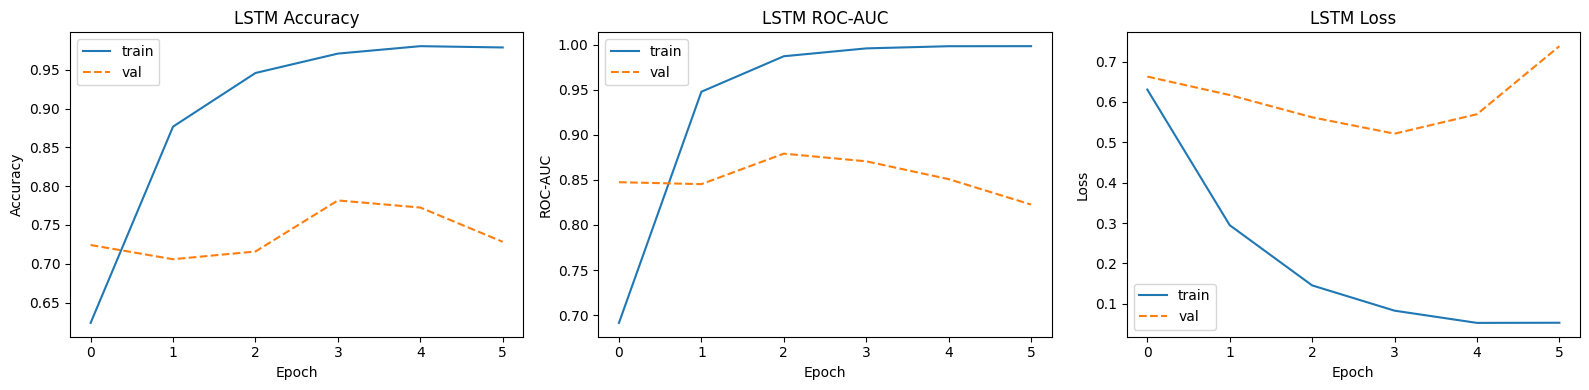


Best LSTM — val acc: 0.7158  |  val AUC: 0.8790


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics_to_plot = [("accuracy", "Accuracy"), ("auc", "ROC-AUC"), ("loss", "Loss")]

for ax, (metric, title) in zip(axes, metrics_to_plot):
    ax.plot(history.history[metric],     label=f"train")
    ax.plot(history.history[f"val_{metric}"], label=f"val", linestyle="--")
    ax.set_title(f"LSTM {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.show()

# Final eval on validation split
loss, acc, auc_val = lstm_model.evaluate(X_val_pad, y_val_lstm, verbose=0)
print(f"\nBest LSTM — val acc: {acc:.4f}  |  val AUC: {auc_val:.4f}")

## 15. Save LSTM Model and Tokenizer

In [21]:
lstm_model_path = MODEL_DIR / "sentiment_lstm.keras"
tokenizer_path  = MODEL_DIR / "tokenizer.joblib"

lstm_model.save(lstm_model_path)
joblib.dump(tokenizer, tokenizer_path, compress=3)

logger.info("LSTM model  → %s  (%.1f KB)", lstm_model_path, lstm_model_path.stat().st_size / 1024)
logger.info("Tokenizer   → %s  (%.1f KB)", tokenizer_path,  tokenizer_path.stat().st_size / 1024)

## 16. Prediction Function — LSTM

In [22]:
def predict_sentiment_lstm(text: str) -> dict:
    """Classify a review with the trained LSTM model."""
    clean       = clean_text(text)
    pad         = texts_to_padded([clean])
    pos_prob    = float(lstm_model.predict(pad, verbose=0)[0][0])
    label       = "positive" if pos_prob >= 0.5 else "negative"
    confidence  = pos_prob if label == "positive" else 1.0 - pos_prob

    return {
        "input_text"    : text,
        "clean_text"    : clean,
        "prediction"    : label,
        "confidence"    : round(confidence, 4),
        "pos_prob"      : round(pos_prob, 4),
        "neg_prob"      : round(1.0 - pos_prob, 4),
    }


for item in examples:
    print(json.dumps(predict_sentiment_lstm(item), indent=2))
    print()

{
  "input_text": "This product is absolutely wonderful and worth every rupee.",
  "clean_text": "this product is absolutely wonderful and worth every rupee",
  "prediction": "positive",
  "confidence": 0.7156,
  "pos_prob": 0.7156,
  "neg_prob": 0.2844
}

{
  "input_text": "The movie was a complete waste of time and very boring.",
  "clean_text": "the movie was a complete waste of time and very boring",
  "prediction": "negative",
  "confidence": 0.5736,
  "pos_prob": 0.4264,
  "neg_prob": 0.5736
}

{
  "input_text": "Delivery was late but the product quality was excellent.",
  "clean_text": "delivery was late but the product quality was excellent",
  "prediction": "positive",
  "confidence": 0.7571,
  "pos_prob": 0.7571,
  "neg_prob": 0.2429
}



## 17. Side-by-Side Model Comparison

In [23]:
print(f"{'Review':<55} {'ML':^10} {'LSTM':^10}")
print("-" * 78)
for item in examples:
    ml_res   = predict_sentiment_ml(item)
    lstm_res = predict_sentiment_lstm(item)
    agree    = "✓" if ml_res["prediction"] == lstm_res["prediction"] else "✗"
    print(
        f"{item[:53]:<55} "
        f"{ml_res['prediction']:^10} "
        f"{lstm_res['prediction']:^10} {agree}"
    )

Review                                                      ML        LSTM   
------------------------------------------------------------------------------
This product is absolutely wonderful and worth every     positive   positive  ✓
The movie was a complete waste of time and very borin    negative   negative  ✓
Delivery was late but the product quality was excelle    positive   positive  ✓


## 18. Generate FastAPI Backend

Run locally:

```bash
cd sentiment_analysis_project
uvicorn app.main:app --reload
```

- API docs: `http://127.0.0.1:8000/docs`
- Web UI : `http://127.0.0.1:8000/`

In [24]:
# clean_text is duplicated here intentionally so main.py is a self-contained file.
api_code = """
from pathlib import Path
import re, string, logging
from typing import Optional

import joblib
import numpy as np
from fastapi import FastAPI, HTTPException
from fastapi.responses import HTMLResponse
from fastapi.staticfiles import StaticFiles
from pydantic import BaseModel, field_validator

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("sentiment_api")

BASE_DIR   = Path(__file__).resolve().parent.parent
MODEL_PATH = BASE_DIR / "models" / "sentiment_model.joblib"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}. Run the notebook first.")

model = joblib.load(MODEL_PATH)
logger.info("Model loaded from %s", MODEL_PATH)

app = FastAPI(title="Sentiment Analysis API", version="2.0.0", description="Classifies text reviews as positive or negative.")

static_dir = Path(__file__).resolve().parent / "static"
if static_dir.exists():
    app.mount("/static", StaticFiles(directory=str(static_dir)), name="static")

_RE_HTML    = re.compile(r"<[^>]+>")
_RE_URL     = re.compile(r"https?://\\\\S+|www\\\\.\\\\S+")
_RE_NONALPH = re.compile(r"[^a-zA-Z\\\\s]")
_RE_SPACES  = re.compile(r"\\\\s+")
_PUNCT_TABLE = str.maketrans("", "", string.punctuation)


def clean_text(text: str) -> str:
    text = str(text).lower()
    text = _RE_HTML.sub(" ", text)
    text = _RE_URL.sub(" ", text)
    text = text.translate(_PUNCT_TABLE)
    text = _RE_NONALPH.sub(" ", text)
    text = _RE_SPACES.sub(" ", text).strip()
    return text


class ReviewRequest(BaseModel):
    text: str

    @field_validator("text")
    @classmethod
    def text_must_not_be_empty(cls, v: str) -> str:
        if not v.strip():
            raise ValueError("text must not be empty")
        return v


class PredictionResponse(BaseModel):
    text: str
    clean_text: str
    prediction: str
    confidence: Optional[float]
    pos_proba: Optional[float]
    neg_proba: Optional[float]


@app.get("/health", tags=["ops"])
def health():
    return {"status": "ok", "model": str(MODEL_PATH.name)}


@app.post("/predict", response_model=PredictionResponse, tags=["inference"])
def predict(payload: ReviewRequest):
    clean = clean_text(payload.text)
    if not clean:
        raise HTTPException(status_code=422, detail="Review is empty after cleaning.")

    pred   = int(model.predict([clean])[0])
    label  = "positive" if pred == 1 else "negative"
    proba  = model.predict_proba([clean])[0]
    conf   = float(proba[pred])

    return PredictionResponse(
        text=payload.text,
        clean_text=clean,
        prediction=label,
        confidence=round(conf, 4),
        pos_proba=round(float(proba[1]), 4),
        neg_proba=round(float(proba[0]), 4),
    )


@app.get("/", response_class=HTMLResponse, include_in_schema=False)
def home():
    index_path = static_dir / "index.html"
    if index_path.exists():
        return index_path.read_text(encoding="utf-8")
    return "<h1>Sentiment Analysis API is running — open /docs</h1>"
"""

(APP_DIR / "main.py").write_text(api_code.strip(), encoding="utf-8")
print("Created:", (APP_DIR / "main.py").resolve())

Created: /content/sentiment_analysis_project/app/main.py


## 19. Generate Web Interface

In [25]:
html_code = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Sentiment Analyser</title>
  <style>
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    body {
      font-family: system-ui, -apple-system, sans-serif;
      background: #f0f2f5;
      min-height: 100vh;
      display: flex;
      align-items: center;
      justify-content: center;
      padding: 24px;
    }
    .card {
      background: #fff;
      border-radius: 16px;
      box-shadow: 0 4px 24px rgba(0,0,0,.10);
      padding: 36px 32px;
      max-width: 680px;
      width: 100%;
    }
    h1 { font-size: 1.5rem; margin-bottom: 6px; }
    p.sub { color: #555; font-size: .9rem; margin-bottom: 20px; }
    textarea {
      width: 100%; min-height: 130px;
      padding: 12px 14px; font-size: 15px;
      border: 1.5px solid #ccc; border-radius: 10px;
      resize: vertical; transition: border-color .2s;
    }
    textarea:focus { outline: none; border-color: #4f46e5; }
    .btn-row { display: flex; gap: 10px; margin-top: 12px; }
    button {
      flex: 1; padding: 12px; border: none; border-radius: 10px;
      font-size: 15px; cursor: pointer; font-weight: 600; transition: opacity .2s;
    }
    button:disabled { opacity: .5; cursor: not-allowed; }
    #analyseBtn { background: #4f46e5; color: #fff; }
    #clearBtn   { background: #e5e7eb; color: #333; }
    #result {
      margin-top: 20px; padding: 18px; border-radius: 10px;
      background: #f8f9fb; border-left: 4px solid #4f46e5;
      font-size: 14px; display: none;
    }
    .badge {
      display: inline-block; padding: 3px 12px; border-radius: 20px;
      font-weight: 700; font-size: 16px; margin-left: 8px;
    }
    .positive { background: #d1fae5; color: #065f46; }
    .negative { background: #fee2e2; color: #991b1b; }
    .bar-wrap { margin-top: 10px; background: #e5e7eb; border-radius: 6px; height: 10px; }
    .bar { height: 10px; border-radius: 6px; transition: width .6s ease; }
    .err { color: #dc2626; }
  </style>
</head>
<body>
<div class="card">
  <h1>Sentiment Analyser</h1>
  <p class="sub">Enter a product, movie, service, or app review to classify it.</p>
  <textarea id="review" placeholder="Type or paste your review here…"></textarea>
  <div class="btn-row">
    <button id="analyseBtn" onclick="analyse()">Analyse</button>
    <button id="clearBtn" onclick="clearAll()">Clear</button>
  </div>
  <div id="result"></div>
</div>

<script>
  async function analyse() {
    const text = document.getElementById("review").value.trim();
    const res  = document.getElementById("result");
    const btn  = document.getElementById("analyseBtn");
    if (!text) { showMsg(res, "Please enter a review first.", true); return; }

    btn.disabled = true;
    btn.textContent = "Analysing…";
    res.style.display = "none";

    try {
      const resp = await fetch("/predict", {
        method: "POST",
        headers: { "Content-Type": "application/json" },
        body: JSON.stringify({ text }),
      });
      if (!resp.ok) {
        const err = await resp.json();
        showMsg(res, "API error: " + (err.detail || resp.statusText), true);
        return;
      }
      const data = await resp.json();
      const pct  = Math.round((data.confidence || 0) * 100);
      const colour = data.prediction === "positive" ? "#10b981" : "#ef4444";
      res.innerHTML = `
        <div><strong>Prediction:</strong>
          <span class="badge ${data.prediction}">${data.prediction.toUpperCase()}</span>
        </div>
        <div style="margin-top:10px"><strong>Confidence:</strong> ${pct}%</div>
        <div class="bar-wrap" style="margin-top:6px">
          <div class="bar" style="width:${pct}%; background:${colour}"></div>
        </div>
        <div style="margin-top:10px; color:#555; font-size:13px">
          Positive: ${(data.pos_proba*100).toFixed(1)}% &nbsp;|&nbsp; Negative: ${(data.neg_proba*100).toFixed(1)}%
        </div>`;
      res.style.display = "block";
    } catch (e) {
      showMsg(res, "Network error: " + e, true);
    } finally {
      btn.disabled = false;
      btn.textContent = "Analyse";
    }
  }

  function clearAll() {
    document.getElementById("review").value = "";
    const res = document.getElementById("result");
    res.style.display = "none";
  }

  function showMsg(el, msg, isErr) {
    el.innerHTML = `<span class="${isErr ? "err" : ""}">${msg}</span>`;
    el.style.display = "block";
  }

  document.getElementById("review").addEventListener("keydown", e => {
    if (e.key === "Enter" && e.ctrlKey) analyse();
  });
</script>
</body>
</html>"""

(STATIC_DIR / "index.html").write_text(html_code.strip(), encoding="utf-8")
print("Created:", (STATIC_DIR / "index.html").resolve())

Created: /content/sentiment_analysis_project/app/static/index.html


## 20. Generate Requirements and Docker Files

In [26]:
# Pin major versions for reproducibility
requirements_txt = """\
fastapi>=0.110,<1.0
uvicorn[standard]>=0.29,<1.0
scikit-learn>=1.4,<2.0
joblib>=1.3,<2.0
pydantic>=2.0,<3.0
numpy>=1.26,<3.0
pandas>=2.0,<3.0
"""

dockerfile_text = """\
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt ./
RUN pip install --no-cache-dir -r requirements.txt

COPY app    ./app
COPY models ./models

EXPOSE 8000

HEALTHCHECK --interval=30s --timeout=5s \\
  CMD python -c "import urllib.request; urllib.request.urlopen('http://localhost:8000/health')"

CMD ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000", "--workers", "2"]
"""

readme_text = """\
# Sentiment Analysis App

Classifies text reviews as **positive** or **negative** using a TF-IDF + Logistic Regression pipeline.

## Quick start

```bash
pip install -r requirements.txt
uvicorn app.main:app --reload
```

Open:
- Web UI  : http://127.0.0.1:8000/
- API docs: http://127.0.0.1:8000/docs

## Docker

```bash
docker build -t sentiment-app .
docker run -p 8000:8000 sentiment-app
```

## API

```bash
curl -X POST http://127.0.0.1:8000/predict \\
     -H "Content-Type: application/json" \\
     -d '{"text": "This product is excellent"}'
```

Response:

```json
{
  "text": "This product is excellent",
  "clean_text": "this product is excellent",
  "prediction": "positive",
  "confidence": 0.9821,
  "pos_proba": 0.9821,
  "neg_proba": 0.0179
}
```
"""

(PROJECT_DIR / "requirements.txt").write_text(requirements_txt, encoding="utf-8")
(PROJECT_DIR / "Dockerfile").write_text(dockerfile_text, encoding="utf-8")
(PROJECT_DIR / "README.md").write_text(readme_text, encoding="utf-8")

for p in ["requirements.txt", "Dockerfile", "README.md"]:
    print("Created:", (PROJECT_DIR / p).resolve())

Created: /content/sentiment_analysis_project/requirements.txt
Created: /content/sentiment_analysis_project/Dockerfile
Created: /content/sentiment_analysis_project/README.md


## 21. Final Inference Test — Load from Disk

In [27]:
loaded_model = joblib.load(MODEL_DIR / "sentiment_model.joblib")

def final_predict(text: str) -> str:
    """One-liner prediction from the saved model file."""
    return "positive" if loaded_model.predict([clean_text(text)])[0] == 1 else "negative"


sample_reviews = [
    "The delivery was late but the product quality was excellent.",
    "The app crashes every time and support is useless.",
    "The film was slow in the beginning but the ending was beautiful.",
    "Absolutely terrible — would not recommend to anyone.",
    "Best purchase I have made all year!",
]

print(f"{'Review':<60} {'Label'}")
print("-" * 70)
for review in sample_reviews:
    print(f"{review[:58]:<60} {final_predict(review)}")

Review                                                       Label
----------------------------------------------------------------------
The delivery was late but the product quality was excellen   positive
The app crashes every time and support is useless.           positive
The film was slow in the beginning but the ending was beau   positive
Absolutely terrible — would not recommend to anyone.         negative
Best purchase I have made all year!                          positive


In [28]:
import os
from google.colab import files

# Zip the project directory
!zip -r sentiment_analysis_project.zip /content/sentiment_analysis_project

# Trigger the download to your local machine
files.download('sentiment_analysis_project.zip')

  adding: content/sentiment_analysis_project/ (stored 0%)
  adding: content/sentiment_analysis_project/requirements.txt (deflated 23%)
  adding: content/sentiment_analysis_project/models/ (stored 0%)
  adding: content/sentiment_analysis_project/models/sentiment_lstm.keras (deflated 38%)
  adding: content/sentiment_analysis_project/models/lstm_best_epoch.keras (deflated 38%)
  adding: content/sentiment_analysis_project/models/tokenizer.joblib (deflated 0%)
  adding: content/sentiment_analysis_project/models/sentiment_model.joblib (deflated 0%)
  adding: content/sentiment_analysis_project/app/ (stored 0%)
  adding: content/sentiment_analysis_project/app/static/ (stored 0%)
  adding: content/sentiment_analysis_project/app/static/index.html (deflated 60%)
  adding: content/sentiment_analysis_project/app/main.py (deflated 57%)
  adding: content/sentiment_analysis_project/README.md (deflated 45%)
  adding: content/sentiment_analysis_project/Dockerfile (deflated 31%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 22. Next Steps & Portfolio Improvements

| Priority | Improvement |
|----------|-------------|
| High | Use a real-world dataset: IMDB 50K, Amazon reviews, Flipkart reviews |
| High | Add neutral class → 3-class classification |
| High | Add unit tests for `clean_text` and `predict_sentiment_ml` |
| Medium | Swap the LSTM for a fine-tuned `bert-base-uncased` or `distilbert` via HuggingFace |
| Medium | Track experiments with MLflow or Weights & Biases |
| Medium | Add Hindi/Hinglish preprocessing for Indian product reviews |
| Low | Deploy to Railway, Render, or GCP Cloud Run |
| Low | Add authentication + rate limiting before public launch |
| Low | Monitor for data drift with Evidently or WhyLabs |

**Output produced by this notebook:**

```
sentiment_analysis_project/
  app/
    main.py          ← FastAPI backend
    static/
      index.html     ← Web UI
  models/
    sentiment_model.joblib   ← TF-IDF + tuned LogReg
    sentiment_lstm.keras     ← Bidirectional LSTM
    tokenizer.joblib         ← Keras tokenizer
  Dockerfile
  requirements.txt
  README.md
```